<a href="https://colab.research.google.com/github/GOE84/Data-science/blob/main/KNN_model_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Basic KNN

Basic KNN K-Nearest Neighbors `(Classification)` Supervised Machine Learning






**หลักการทำงาน**


*   ดูเพื่อนบ้าน (Neighbors): เมื่อมีข้อมูลใหม่เข้ามา โมเดลจะคำนวณหาระยะห่างจากข้อมูลเดิมที่มีอยู่
*   กำหนดค่า K: เลือกจำนวนเพื่อนบ้านที่ใกล้ที่สุดตามค่า K ที่กำหนดไว้ (เช่น ถ้า K=3 จะดูข้อมูลที่ใกล้ที่สุด 3 จุด)






> งาน Classification จะใช้เสียงข้างมากจากเพื่อนบ้านกลุ่มนั้นมาเป็นคำตอบ

> งาน Regression จะหาค่าเฉลี่ยของเพื่อนบ้านกลุ่มนั้น






In [54]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [55]:
df = pd.read_csv('/content/iris_data.csv')

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Id       10 non-null     int64  
 1   SL       10 non-null     float64
 2   SW       10 non-null     float64
 3   PL       10 non-null     float64
 4   PW       10 non-null     float64
 5   Species  10 non-null     object 
dtypes: float64(4), int64(1), object(1)
memory usage: 612.0+ bytes


In [57]:
df

,Id,SL,SW,PL,PW,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,51,7.0,3.2,4.7,1.4,Iris-versicolor
6,52,6.4,3.2,4.5,1.5,Iris-versicolor
7,53,6.9,3.1,4.9,1.5,Iris-versicolor
8,54,5.5,2.3,4.0,1.3,Iris-versicolor
9,55,6.5,2.8,4.6,1.5,Iris-versicolor


In [58]:
x = df.drop(['Id','Species'],axis=1)
y = df['Species']

In [59]:
X = x.values.reshape(-1,4)
Y = y.values.reshape(-1,1)

In [60]:
from sklearn.neighbors import KNeighborsClassifier as KNN

In [61]:
k=3

In [62]:
pre = KNN(n_neighbors=k)

In [63]:
pre.fit(X,Y)

/usr/local/lib/python3.13/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(n_neighbors=3)

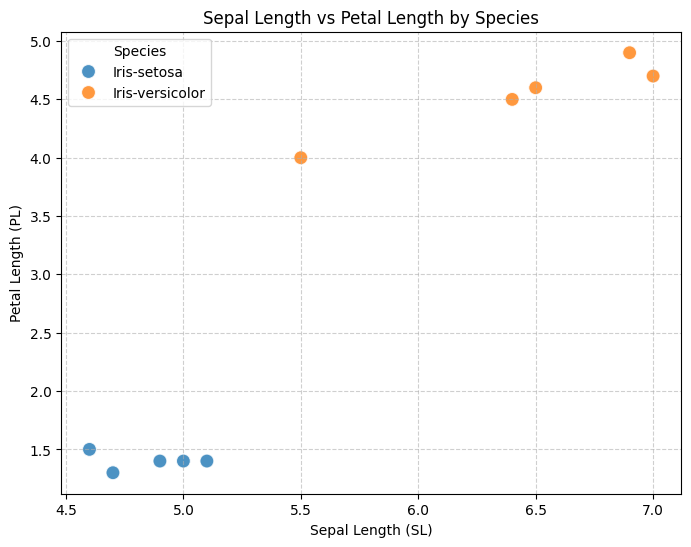

In [64]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='SL', y='PL', hue='Species', data=df, s=100, alpha=0.8)
plt.title('Sepal Length vs Petal Length by Species')
plt.xlabel('Sepal Length (SL)')
plt.ylabel('Petal Length (PL)')
plt.legend(title='Species')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [65]:
Y_pred = pre.predict(X)
print("Predicted Species:")
for i, pred in enumerate(Y_pred):
    print(f"Sample {i+1}: {pred}")

Predicted Species:
Sample 1: Iris-setosa
Sample 2: Iris-setosa
Sample 3: Iris-setosa
Sample 4: Iris-setosa
Sample 5: Iris-setosa
Sample 6: Iris-versicolor
Sample 7: Iris-versicolor
Sample 8: Iris-versicolor
Sample 9: Iris-versicolor
Sample 10: Iris-versicolor


In [69]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

In [70]:
pre.fit(X_train, Y_train)

Y_pred_test = pre.predict(X_test)

/usr/local/lib/python3.13/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


### Model Evaluation

In [71]:
accuracy = accuracy_score(Y_test, Y_pred_test)
print(f"Accuracy Score: {accuracy:.2f}")

# Display Confusion Matrix
conf_matrix = confusion_matrix(Y_test, Y_pred_test)
print("\nConfusion Matrix:")
print(conf_matrix)

class_report = classification_report(Y_test, Y_pred_test)
print("\nClassification Report:")
print(class_report)

Accuracy Score: 1.00

Confusion Matrix:
[[1 0]
 [0 2]]

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         1
Iris-versicolor       1.00      1.00      1.00         2

       accuracy                           1.00         3
      macro avg       1.00      1.00      1.00         3
   weighted avg       1.00      1.00      1.00         3

